# Exploratory Analysis of Bitcoin Realized Volatility

This notebook focuses on Bitcoin volatility, not return direction. The goal is to forecast **next-day realized volatility**.

Realized volatility is calculated from 5-minute BTC returns:

$$
r_{t,i} = \log\left(\frac{P_{t,i}}{P_{t,i-1}}\right)
$$

$$
RV_t = \sqrt{\sum_{i=1}^{n_t} r_{t,i}^{2}}
$$

$$
\text{target}_t = RV_{t+1}
$$

So for day \(t\), we use information available up to that day and the target is volatility on the next day. The value is kept on the normal scale, for example \(0.025\) means about **2.5% daily volatility**.

## 1. Exploratory Data Analysis

In [1]:
from pathlib import Path
import json
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.6f}".format

In [2]:
DAILY_DATA_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.csv")
METADATA_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.metadata.json")
SCALER_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.scaler.pkl")
RAW_5MIN_PATH = Path("data/BTC/BTC_USD_coinbase_spot_5min.csv")

### Load Daily Features

The daily feature file is used mainly for daily OHLCV data and the existing train/test split. Some numeric columns in this file are scaled, so we invert the scaler before using prices and returns.

In [3]:
daily_scaled = pd.read_csv(DAILY_DATA_PATH, parse_dates=["timestamp_utc"])

with METADATA_PATH.open("r", encoding="utf-8") as file:
    metadata = json.load(file)

with SCALER_PATH.open("rb") as file:
    scaler = pickle.load(file)

scaled_columns = metadata["scaled_columns"]
daily_full = daily_scaled.copy()
daily_full[scaled_columns] = scaler.inverse_transform(daily_scaled[scaled_columns])

daily_full = daily_full.set_index("timestamp_utc").sort_index()
daily_full.head()

,open,high,low,close,volume,product_id,source,observations,expected_observations,coverage_ratio,...,volume_log_lag_1,log_return_lag_2,volume_log_lag_2,log_return_lag_3,volume_log_lag_3,log_return_lag_7,volume_log_lag_7,target_log_return_next,target_direction_next,split
timestamp_utc,,,,,,,,,,,,,,,,,,,,,
2016-05-14 00:00:00+00:00,457.970000,459.830000,456.000000,458.900000,"3,295.199707",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.595118,0.004633,8.719325,0.003505,8.656504,-0.000866,8.150433,0.005585,1.000000,train
2016-05-15 00:00:00+00:00,458.900000,463.620000,458.490000,461.470000,"3,269.982525",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.100525,0.003281,8.595118,0.004633,8.719325,0.001903,8.094555,-0.012670,0.000000,train
2016-05-16 00:00:00+00:00,461.480000,461.590000,451.480000,455.660000,"6,019.172367",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.092846,0.002007,8.100525,0.003281,8.595118,0.002956,8.679982,-0.003231,0.000000,train
2016-05-17 00:00:00+00:00,455.640000,457.490000,452.200000,454.190000,"6,033.908426",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.702871,0.005585,8.092846,0.002007,8.100525,-0.024823,8.826919,0.003012,1.000000,train
2016-05-18 00:00:00+00:00,454.190000,457.880000,453.600000,455.560000,"5,512.423782",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.705316,-0.012670,8.702871,0.005585,8.092846,0.003505,8.656504,-0.038441,0.000000,train


### Build Daily Realized Volatility from 5-Minute Prices

The volatility target is calculated from raw 5-minute data. Daily close-to-close returns can miss large intraday price movements.

In [4]:
raw_5min = pd.read_csv(RAW_5MIN_PATH, parse_dates=["timestamp_utc"])
raw_5min = raw_5min.sort_values("timestamp_utc").set_index("timestamp_utc")

raw_5min["log_close"] = np.log(raw_5min["close"])
raw_5min["intraday_log_return"] = raw_5min["log_close"].diff()
raw_5min["intraday_squared_return"] = raw_5min["intraday_log_return"] ** 2

realized_volatility = raw_5min["intraday_squared_return"].resample("1D").sum().pow(0.5)
realized_observations = raw_5min["intraday_log_return"].resample("1D").count()

realized_daily = pd.DataFrame({
    "realized_volatility": realized_volatility,
    "realized_observations": realized_observations,
})
realized_daily["realized_variance"] = realized_daily["realized_volatility"] ** 2
realized_daily["realized_volatility_pct"] = realized_daily["realized_volatility"] * 100
realized_daily.head()

,realized_volatility,realized_observations,realized_variance,realized_volatility_pct
timestamp_utc,,,,
2016-04-13 00:00:00+00:00,0.006405,82,0.000041,0.640513
2016-04-14 00:00:00+00:00,0.009101,278,0.000083,0.910057
2016-04-15 00:00:00+00:00,0.008232,278,0.000068,0.823219
2016-04-16 00:00:00+00:00,0.008115,287,0.000066,0.811503
2016-04-17 00:00:00+00:00,0.010180,286,0.000104,1.017991


In [5]:
daily_full = daily_full.join(realized_daily, how="left")
daily_full["target_realized_volatility_next"] = daily_full["realized_volatility"].shift(-1)
daily_full["log_realized_volatility"] = np.log(daily_full["realized_volatility"])

daily_full[[
    "close",
    "log_return",
    "realized_volatility",
    "realized_volatility_pct",
    "target_realized_volatility_next",
    "split",
]].head()

,close,log_return,realized_volatility,realized_volatility_pct,target_realized_volatility_next,split
timestamp_utc,,,,,,
2016-05-14 00:00:00+00:00,458.900000,0.002007,0.007552,0.755233,0.006824,train
2016-05-15 00:00:00+00:00,461.470000,0.005585,0.006824,0.682375,0.011054,train
2016-05-16 00:00:00+00:00,455.660000,-0.012670,0.011054,1.105422,0.011140,train
2016-05-17 00:00:00+00:00,454.190000,-0.003231,0.011140,1.114000,0.008932,train
2016-05-18 00:00:00+00:00,455.560000,0.003012,0.008932,0.893241,0.022536,train


### Final Forecasting Setup

For the later models: use data up to day t -> predict RV_{t+1}

`RV_t` is calculated from all 5-minute returns inside day `t`. This keeps the target daily, but it still uses intraday information.

### Dataset Overview

The EDA below uses only the training period. The test period is kept separate for later model evaluation.

In [6]:
train_daily = daily_full.loc[daily_full["split"] == "train"].copy()
test_daily = daily_full.loc[daily_full["split"] == "test"].copy()

# Use only the training split for exploratory analysis and statistical diagnostics.
daily = train_daily.copy()

print(f"Full rows: {len(daily_full):,}")
print(f"Training rows used below: {len(daily):,}")
print(f"Test rows held out: {len(test_daily):,}")
print(f"Columns: {daily_full.shape[1]}")
print(f"Training start date: {daily.index.min().date()}")
print(f"Training end date: {daily.index.max().date()}")
print(f"Test start date: {test_daily.index.min().date()}")
print(f"Test end date: {test_daily.index.max().date()}")
print(f"Training missing values: {daily.isna().sum().sum()}")
print(f"Duplicated dates in full data: {daily_full.index.duplicated().sum()}")

Full rows: 3,595
Training rows used below: 2,876
Test rows held out: 719
Columns: 48
Training start date: 2016-05-14
Training end date: 2024-04-21
Test start date: 2024-04-22
Test end date: 2026-04-11
Training missing values: 0
Duplicated dates in full data: 0


In [7]:
daily[[
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_return",
    "realized_volatility",
    "target_realized_volatility_next",
    "split",
]].head()

,open,high,low,close,volume,log_return,realized_volatility,target_realized_volatility_next,split
timestamp_utc,,,,,,,,,
2016-05-14 00:00:00+00:00,457.970000,459.830000,456.000000,458.900000,"3,295.199707",0.002007,0.007552,0.006824,train
2016-05-15 00:00:00+00:00,458.900000,463.620000,458.490000,461.470000,"3,269.982525",0.005585,0.006824,0.011054,train
2016-05-16 00:00:00+00:00,461.480000,461.590000,451.480000,455.660000,"6,019.172367",-0.012670,0.011054,0.011140,train
2016-05-17 00:00:00+00:00,455.640000,457.490000,452.200000,454.190000,"6,033.908426",-0.003231,0.011140,0.008932,train
2016-05-18 00:00:00+00:00,454.190000,457.880000,453.600000,455.560000,"5,512.423782",0.003012,0.008932,0.022536,train


### Missing Values and Daily Coverage

In [8]:
missing_values = daily.isna().sum().to_frame("missing_values")
missing_values["missing_share"] = missing_values["missing_values"] / len(daily)

missing_values[missing_values["missing_values"] > 0]

,missing_values,missing_share


In [9]:
daily[[
    "observations",
    "expected_observations",
    "coverage_ratio",
    "realized_observations",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
observations,"2,876.000000",287.883171,0.914947,274.000000,288.000000,288.000000,288.000000,288.000000
expected_observations,"2,876.000000",288.000000,0.000000,288.000000,288.000000,288.000000,288.000000,288.000000
coverage_ratio,"2,876.000000",0.999594,0.003177,0.951389,1.000000,1.000000,1.000000,1.000000
realized_observations,"2,876.000000",287.883171,0.914947,274.000000,288.000000,288.000000,288.000000,288.000000


In [10]:
date_gaps = daily.index.to_series().diff()
date_gaps.value_counts().head(10)

timestamp_utc
1 days    2854
2 days      19
3 days       1
4 days       1
Name: count, dtype: int64

In [11]:
long_gaps = date_gaps[date_gaps > pd.Timedelta(days=1)]

gap_details = pd.DataFrame({
    "previous_date": [daily.index[daily.index.get_loc(date) - 1] for date in long_gaps.index],
    "current_date": long_gaps.index,
    "gap_length": long_gaps.values,
})

gap_details.head(30)

,previous_date,current_date,gap_length
0,2016-07-10 00:00:00+00:00,2016-07-12 00:00:00+00:00,2 days
1,2016-09-18 00:00:00+00:00,2016-09-20 00:00:00+00:00,2 days
2,2016-10-14 00:00:00+00:00,2016-10-17 00:00:00+00:00,3 days
3,2017-01-15 00:00:00+00:00,2017-01-17 00:00:00+00:00,2 days
4,2017-02-27 00:00:00+00:00,2017-03-03 00:00:00+00:00,4 days
5,2017-04-14 00:00:00+00:00,2017-04-16 00:00:00+00:00,2 days
6,2017-09-24 00:00:00+00:00,2017-09-26 00:00:00+00:00,2 days
7,2017-11-30 00:00:00+00:00,2017-12-02 00:00:00+00:00,2 days
8,2017-12-11 00:00:00+00:00,2017-12-13 00:00:00+00:00,2 days
9,2018-01-31 00:00:00+00:00,2018-02-02 00:00:00+00:00,2 days


### Summary Statistics

In [12]:
main_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_return",
    "realized_volatility",
    "realized_volatility_pct",
    "target_realized_volatility_next",
]

daily[main_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
open,"2,876.000000","19,230.301516","17,750.227910",437.910000,"6,182.212500","10,761.145000","29,944.395000","73,135.040000"
high,"2,876.000000","19,724.111318","18,205.686873",445.850000,"6,327.085000","11,042.000000","30,514.187500","73,835.570000"
low,"2,876.000000","18,689.424871","17,240.955405",435.000000,"5,915.907500","10,357.825000","29,366.237500","71,337.300000"
close,"2,876.000000","19,252.577827","17,767.239204",438.380000,"6,187.565000","10,761.145000","29,997.347500","73,135.040000"
volume,"2,876.000000","15,382.968834","12,024.176569","1,315.729558","7,307.838495","12,412.803049","19,570.020540","130,316.646844"
log_return,"2,876.000000",0.001723,0.038554,-0.491226,-0.013254,0.001555,0.018310,0.240606
realized_volatility,"2,876.000000",0.034095,0.025684,0.003096,0.018461,0.027738,0.041274,0.329193
realized_volatility_pct,"2,876.000000",3.409476,2.568381,0.309584,1.846068,2.773835,4.127415,32.919344
target_realized_volatility_next,"2,876.000000",0.034101,0.025679,0.003096,0.018476,0.027738,0.041274,0.329193


In [13]:
highest_volatility_date = daily["realized_volatility"].idxmax()
lowest_volatility_date = daily["realized_volatility"].idxmin()

print("Highest daily realized volatility:")
print(highest_volatility_date.date(), f"{daily.loc[highest_volatility_date, 'realized_volatility_pct']:.2f}%")

print("\nLowest daily realized volatility:")
print(lowest_volatility_date.date(), f"{daily.loc[lowest_volatility_date, 'realized_volatility_pct']:.2f}%")

Highest daily realized volatility:
2020-03-13 32.92%

Lowest daily realized volatility:
2023-08-12 0.31%


### Price, Volume, and Realized Volatility

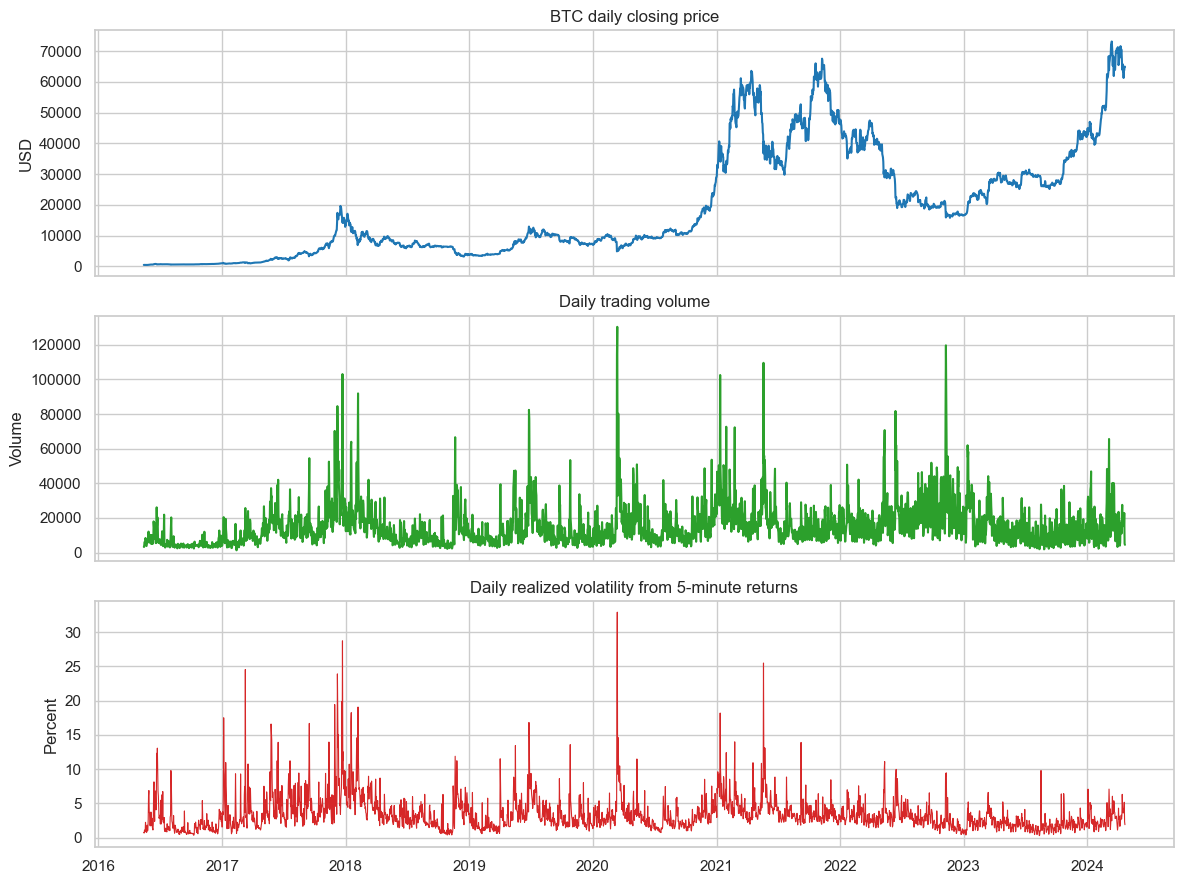

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(daily.index, daily["close"], color="tab:blue")
axes[0].set_title("BTC daily closing price")
axes[0].set_ylabel("USD")

axes[1].plot(daily.index, daily["volume"], color="tab:green")
axes[1].set_title("Daily trading volume")
axes[1].set_ylabel("Volume")

axes[2].plot(daily.index, daily["realized_volatility_pct"], color="tab:red", linewidth=0.8)
axes[2].set_title("Daily realized volatility from 5-minute returns")
axes[2].set_ylabel("Percent")

plt.tight_layout()
plt.show()

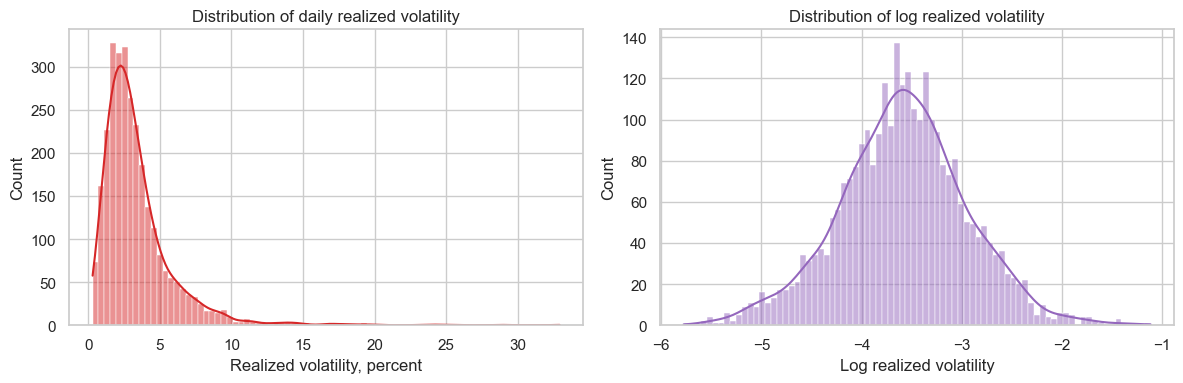

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(daily["realized_volatility_pct"], bins=80, kde=True, ax=axes[0], color="tab:red")
axes[0].set_title("Distribution of daily realized volatility")
axes[0].set_xlabel("Realized volatility, percent")

sns.histplot(daily["log_realized_volatility"].dropna(), bins=80, kde=True, ax=axes[1], color="tab:purple")
axes[1].set_title("Distribution of log realized volatility")
axes[1].set_xlabel("Log realized volatility")

plt.tight_layout()
plt.show()

## 2. Trend, Seasonality, and Volatility

This section checks how realized volatility behaves over time. We look at trend, calendar patterns, and volatility clustering.

### Trend

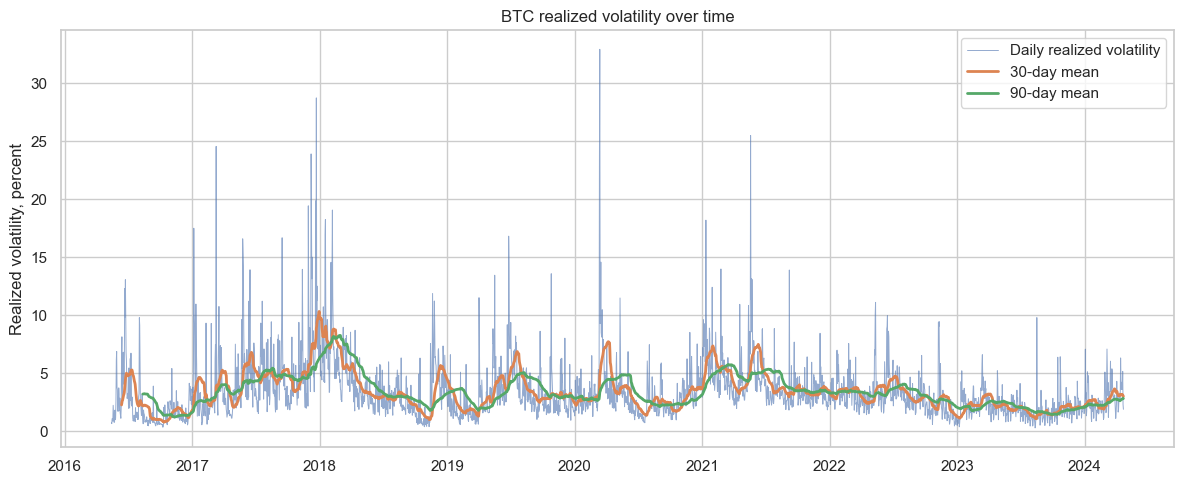

In [16]:
daily["realized_volatility_30d_mean"] = daily["realized_volatility"].rolling(30).mean()
daily["realized_volatility_90d_mean"] = daily["realized_volatility"].rolling(90).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily["realized_volatility_pct"], label="Daily realized volatility", linewidth=0.7, alpha=0.6)
plt.plot(daily.index, daily["realized_volatility_30d_mean"] * 100, label="30-day mean", linewidth=2)
plt.plot(daily.index, daily["realized_volatility_90d_mean"] * 100, label="90-day mean", linewidth=2)
plt.title("BTC realized volatility over time")
plt.ylabel("Realized volatility, percent")
plt.legend()
plt.tight_layout()
plt.show()

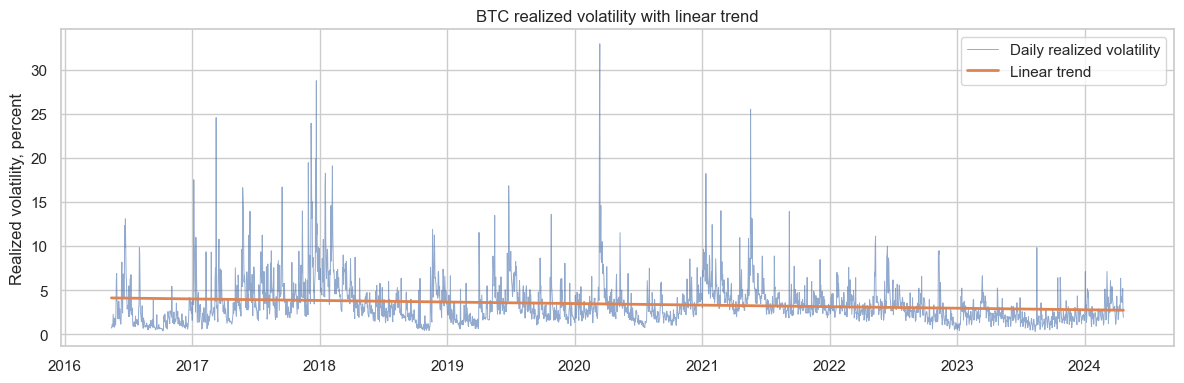

In [17]:
volatility_trend_data = daily["realized_volatility"].dropna()
x = np.arange(len(volatility_trend_data))
trend_coef = np.polyfit(x, volatility_trend_data, 1)
trend_line = np.polyval(trend_coef, x)

plt.figure(figsize=(12, 4))
plt.plot(volatility_trend_data.index, volatility_trend_data * 100, label="Daily realized volatility", linewidth=0.7, alpha=0.6)
plt.plot(volatility_trend_data.index, trend_line * 100, label="Linear trend", linewidth=2)
plt.title("BTC realized volatility with linear trend")
plt.ylabel("Realized volatility, percent")
plt.legend()
plt.tight_layout()
plt.show()

### Seasonality

In [18]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily["weekday"] = daily.index.day_name()
daily["month"] = daily.index.month_name()

weekday_summary = daily.groupby("weekday")["realized_volatility"].agg(
    days="count",
    mean_volatility="mean",
    median_volatility="median",
    volatility_of_volatility="std",
).reindex(weekday_order)

weekday_summary.assign(
    mean_volatility_pct=weekday_summary["mean_volatility"] * 100,
    median_volatility_pct=weekday_summary["median_volatility"] * 100,
)

,days,mean_volatility,median_volatility,volatility_of_volatility,mean_volatility_pct,median_volatility_pct
weekday,,,,,,
Monday,409,0.034253,0.028811,0.022094,3.425329,2.881067
Tuesday,411,0.035106,0.028918,0.023498,3.510622,2.891767
Wednesday,412,0.037030,0.030307,0.026909,3.703007,3.030670
Thursday,406,0.036987,0.029040,0.028538,3.698672,2.904039
Friday,412,0.036724,0.029418,0.032033,3.672371,2.941842
Saturday,412,0.028800,0.022724,0.021653,2.880028,2.272424
Sunday,414,0.029829,0.023650,0.021994,2.982946,2.365009


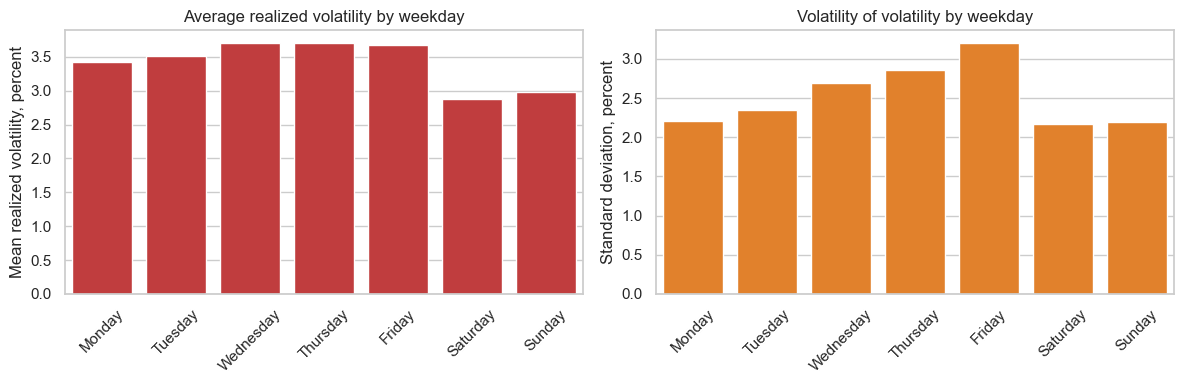

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

weekday_plot = weekday_summary.reset_index()
weekday_plot["mean_volatility_pct"] = weekday_plot["mean_volatility"] * 100
weekday_plot["volatility_of_volatility_pct"] = weekday_plot["volatility_of_volatility"] * 100

sns.barplot(
    data=weekday_plot,
    x="weekday",
    y="mean_volatility_pct",
    ax=axes[0],
    color="tab:red",
)
axes[0].set_title("Average realized volatility by weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean realized volatility, percent")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=weekday_plot,
    x="weekday",
    y="volatility_of_volatility_pct",
    ax=axes[1],
    color="tab:orange",
)
axes[1].set_title("Volatility of volatility by weekday")
axes[1].set_xlabel("")
axes[1].set_ylabel("Standard deviation, percent")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [20]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

monthly_summary = daily.groupby("month")["realized_volatility"].agg(
    days="count",
    mean_volatility="mean",
    median_volatility="median",
    volatility_of_volatility="std",
).reindex(month_order)

monthly_summary.assign(
    mean_volatility_pct=monthly_summary["mean_volatility"] * 100,
    median_volatility_pct=monthly_summary["median_volatility"] * 100,
)

,days,mean_volatility,median_volatility,volatility_of_volatility,mean_volatility_pct,median_volatility_pct
month,,,,,,
January,246,0.040296,0.030093,0.029638,4.029593,3.009288
February,224,0.035308,0.027646,0.025818,3.530815,2.764626
March,245,0.041325,0.035450,0.033598,4.132499,3.544984
April,229,0.030081,0.026747,0.015300,3.008105,2.674720
May,234,0.041079,0.033749,0.030248,4.107880,3.374921
June,238,0.040049,0.033377,0.025112,4.004940,3.337689
July,247,0.031671,0.028257,0.019397,3.167098,2.825706
August,247,0.028580,0.025883,0.016502,2.858034,2.588272
September,238,0.028098,0.022638,0.020582,2.809845,2.263831


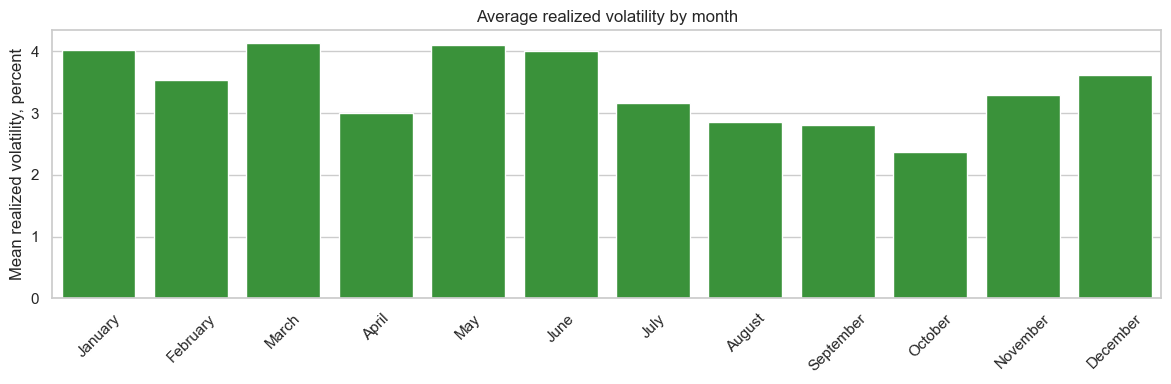

In [21]:
monthly_plot = monthly_summary.reset_index()
monthly_plot["mean_volatility_pct"] = monthly_plot["mean_volatility"] * 100

plt.figure(figsize=(12, 4))
sns.barplot(
    data=monthly_plot,
    x="month",
    y="mean_volatility_pct",
    color="tab:green",
)
plt.title("Average realized volatility by month")
plt.xlabel("")
plt.ylabel("Mean realized volatility, percent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Volatility Clustering

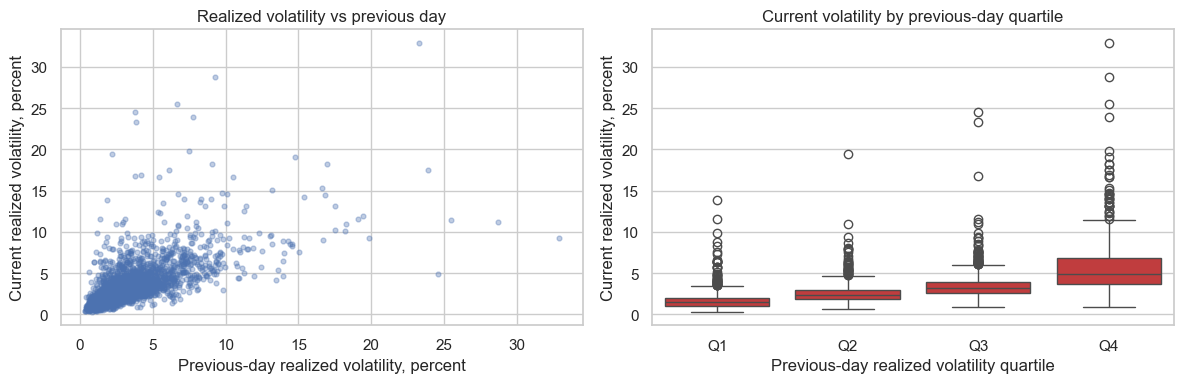

In [22]:
daily["realized_volatility_lag_1"] = daily["realized_volatility"].shift(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(
    daily["realized_volatility_lag_1"] * 100,
    daily["realized_volatility"] * 100,
    alpha=0.35,
    s=12,
)
axes[0].set_title("Realized volatility vs previous day")
axes[0].set_xlabel("Previous-day realized volatility, percent")
axes[0].set_ylabel("Current realized volatility, percent")

sns.boxplot(
    data=daily.assign(
        volatility_quartile=pd.qcut(daily["realized_volatility_lag_1"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
    ),
    x="volatility_quartile",
    y="realized_volatility_pct",
    ax=axes[1],
    color="tab:red",
)
axes[1].set_title("Current volatility by previous-day quartile")
axes[1].set_xlabel("Previous-day realized volatility quartile")
axes[1].set_ylabel("Current realized volatility, percent")

plt.tight_layout()
plt.show()

In [23]:
high_volatility_days = daily.sort_values("realized_volatility", ascending=False)[
    ["close", "log_return", "realized_volatility_pct", "volume"]
].head(10)

high_volatility_days

,close,log_return,realized_volatility_pct,volume
timestamp_utc,,,,
2020-03-13 00:00:00+00:00,"5,637.600000",0.149017,32.919344,"130,316.646844"
2017-12-22 00:00:00+00:00,"14,210.570000",-0.103413,28.735104,"103,039.934213"
2021-05-19 00:00:00+00:00,"36,731.750000",-0.154231,25.498334,"109,537.242333"
2017-03-10 00:00:00+00:00,"1,109.010000",-0.076601,24.557473,"25,699.707479"
2017-12-07 00:00:00+00:00,"17,390.010000",0.210431,23.910078,"84,528.102371"
2020-03-12 00:00:00+00:00,"4,857.100000",-0.491226,23.306892,"113,902.203329"
2017-12-20 00:00:00+00:00,"16,496.890000",-0.078200,19.861490,"47,992.444244"
2017-11-29 00:00:00+00:00,"9,935.980000",-0.001310,19.438314,"70,224.997020"
2018-02-06 00:00:00+00:00,"7,688.460000",0.107447,19.076341,"91,895.110627"


## 3. Stationarity and Autocorrelation

This section checks if realized volatility is stable enough to model and if past volatility is related to future volatility.

### Stationarity Tests

In [24]:
def stationarity_tests(series, series_name):
    clean_series = series.dropna()
    adf_result = adfuller(clean_series, autolag="AIC")
    kpss_result = kpss(clean_series, regression="c", nlags="auto")

    return pd.Series({
        "series": series_name,
        "observations": len(clean_series),
        "adf_statistic": adf_result[0],
        "adf_pvalue": adf_result[1],
        "kpss_statistic": kpss_result[0],
        "kpss_pvalue": kpss_result[1],
    })

In [25]:
stationarity_summary = pd.DataFrame([
    stationarity_tests(daily["close"], "close price"),
    stationarity_tests(daily["log_close"], "log close price"),
    stationarity_tests(daily["log_return"], "daily log return"),
    stationarity_tests(daily["realized_volatility"], "realized volatility"),
    stationarity_tests(daily["log_realized_volatility"], "log realized volatility"),
])

stationarity_summary

,series,observations,adf_statistic,adf_pvalue,kpss_statistic,kpss_pvalue
0,close price,2876,-1.066348,0.728304,5.607333,0.010000
1,log close price,2876,-2.044257,0.267511,6.981373,0.010000
2,daily log return,2876,-37.219589,0.000000,0.212566,0.100000
3,realized volatility,2876,-6.152559,0.000000,0.912134,0.010000
4,log realized volatility,2876,-5.104010,0.000014,0.583632,0.024124


The stationarity tests show that the BTC close price and log close price are non-stationary. Their ADF p-values are high, so we fail to reject the presence of a unit root, while the KPSS p-values are low, so we reject stationarity.

Daily log returns appear stationary. The ADF p-value is close to zero and the KPSS p-value is high, which means the return series is suitable for time series modeling without additional differencing.

For realized volatility and log realized volatility, the results are mixed. The ADF test suggests stationarity because the p-values are very low, but the KPSS test rejects stationarity. This means volatility does not behave like a random walk, but it may still contain persistent changes, volatility regimes, or slow-moving trends.

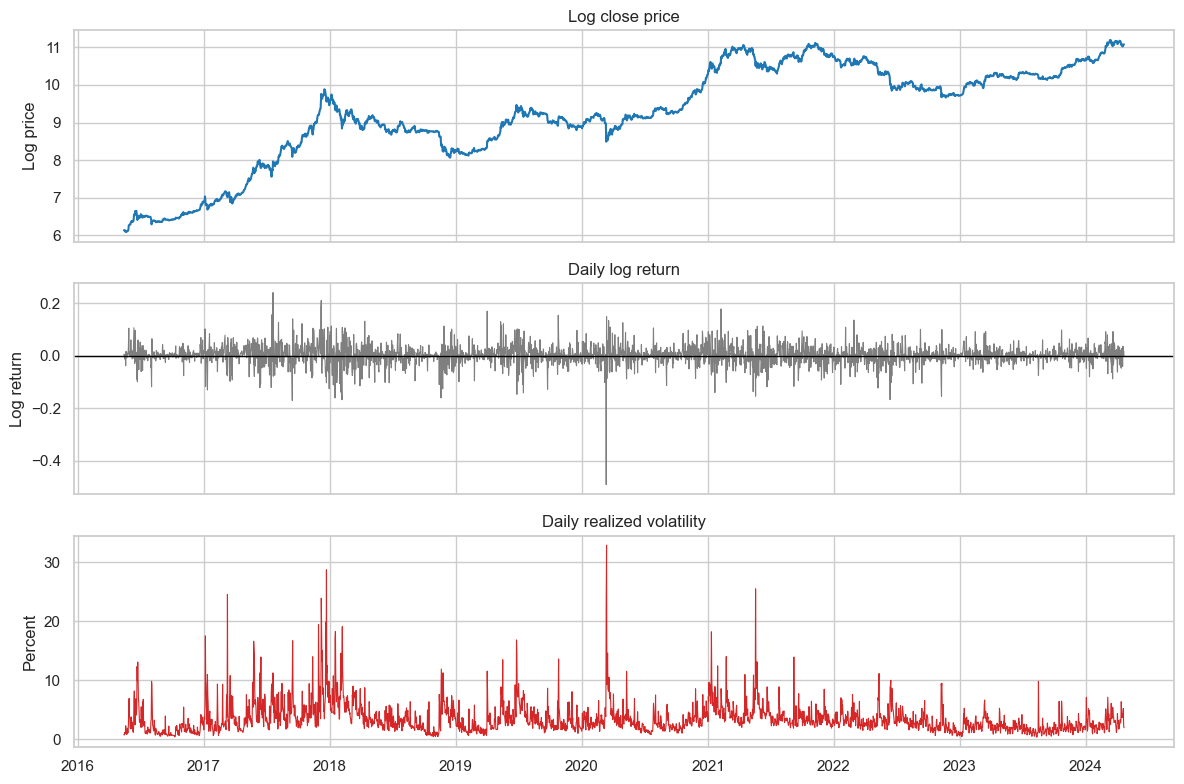

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(daily.index, daily["log_close"], color="tab:blue")
axes[0].set_title("Log close price")
axes[0].set_ylabel("Log price")

axes[1].plot(daily.index, daily["log_return"], color="tab:gray", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Daily log return")
axes[1].set_ylabel("Log return")

axes[2].plot(daily.index, daily["realized_volatility_pct"], color="tab:red", linewidth=0.8)
axes[2].set_title("Daily realized volatility")
axes[2].set_ylabel("Percent")

plt.tight_layout()
plt.show()

### Autocorrelation Plots

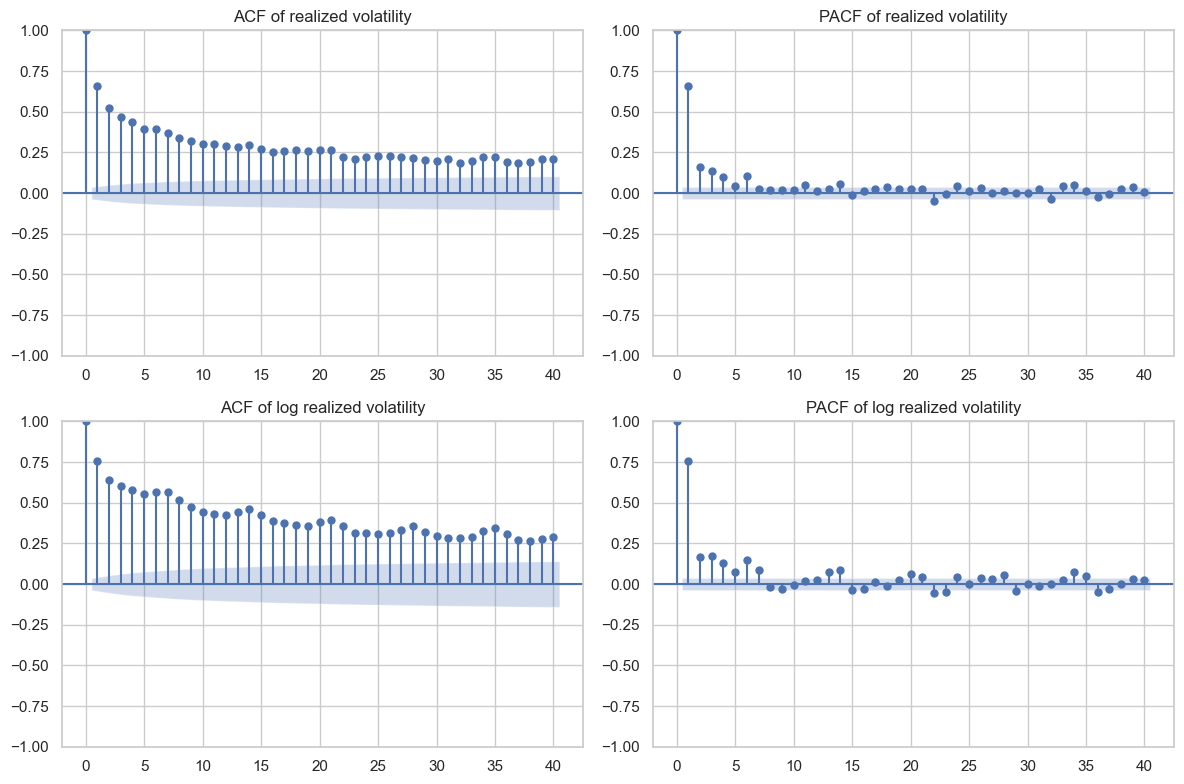

In [27]:
realized_vol = daily["realized_volatility"].dropna()
log_realized_vol = daily["log_realized_volatility"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(realized_vol, lags=40, ax=axes[0, 0])
plot_pacf(realized_vol, lags=40, ax=axes[0, 1], method="ywm")
plot_acf(log_realized_vol, lags=40, ax=axes[1, 0])
plot_pacf(log_realized_vol, lags=40, ax=axes[1, 1], method="ywm")

axes[0, 0].set_title("ACF of realized volatility")
axes[0, 1].set_title("PACF of realized volatility")
axes[1, 0].set_title("ACF of log realized volatility")
axes[1, 1].set_title("PACF of log realized volatility")

plt.tight_layout()
plt.show()

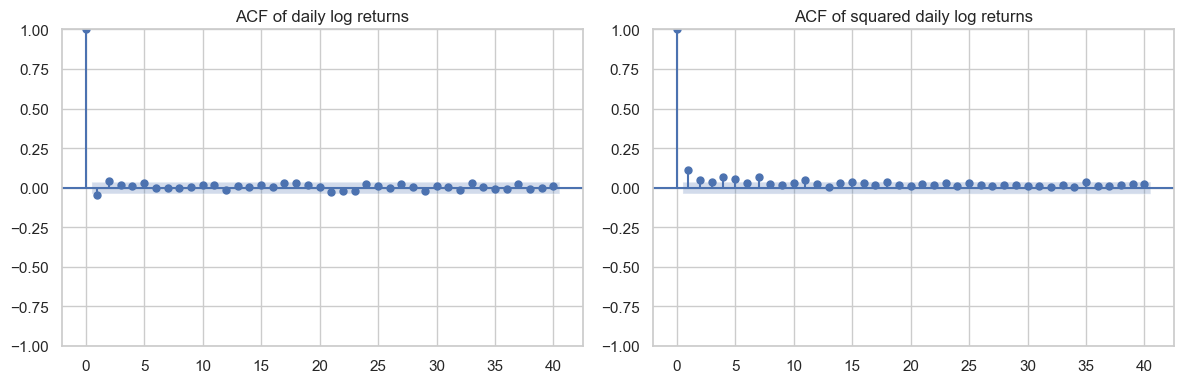

In [28]:
returns = daily["log_return"].dropna()
squared_returns = (daily["log_return"] ** 2).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(returns, lags=40, ax=axes[0])
plot_acf(squared_returns, lags=40, ax=axes[1])
axes[0].set_title("ACF of daily log returns")
axes[1].set_title("ACF of squared daily log returns")
plt.tight_layout()
plt.show()

### Ljung-Box Tests

In [29]:
ljung_lags = [5, 10, 20]

ljung_inputs = {
    "daily log return": returns,
    "squared daily log return": squared_returns,
    "realized volatility": realized_vol,
    "log realized volatility": log_realized_vol,
}

ljung_rows = []
for series_name, series_values in ljung_inputs.items():
    result = acorr_ljungbox(series_values, lags=ljung_lags, return_df=True)
    result["series"] = series_name
    result.index.name = "lag"
    ljung_rows.append(result.reset_index())

ljung_box_summary = pd.concat(ljung_rows, ignore_index=True)[
    ["series", "lag", "lb_stat", "lb_pvalue"]
]

ljung_box_summary

,series,lag,lb_stat,lb_pvalue
0,daily log return,5,15.988085,0.006878
1,daily log return,10,16.953575,0.075398
2,daily log return,20,25.552091,0.181120
3,squared daily log return,5,66.920866,0.000000
4,squared daily log return,10,85.325117,0.000000
5,squared daily log return,20,107.169079,0.000000
6,realized volatility,5,"3,653.257676",0.000000
7,realized volatility,10,"5,385.754864",0.000000
8,realized volatility,20,"7,567.048455",0.000000
9,log realized volatility,5,"5,697.730719",0.000000


In [30]:
ljung_box_summary.assign(significant=ljung_box_summary["lb_pvalue"] < 0.05)

,series,lag,lb_stat,lb_pvalue,significant
0,daily log return,5,15.988085,0.006878,True
1,daily log return,10,16.953575,0.075398,False
2,daily log return,20,25.552091,0.181120,False
3,squared daily log return,5,66.920866,0.000000,True
4,squared daily log return,10,85.325117,0.000000,True
5,squared daily log return,20,107.169079,0.000000,True
6,realized volatility,5,"3,653.257676",0.000000,True
7,realized volatility,10,"5,385.754864",0.000000,True
8,realized volatility,20,"7,567.048455",0.000000,True
9,log realized volatility,5,"5,697.730719",0.000000,True


The Ljung-Box test shows that daily log returns have only weak autocorrelation. The p-value is significant at lag 5, but not at lags 10 and 20, so the dependence in returns is limited and mostly short-term.

Squared daily log returns are significant at all tested lags, which indicates volatility clustering. This means that large return movements tend to be followed by other large movements, and calm periods tend to persist.

Realized volatility and log realized volatility show very strong autocorrelation at all tested lags. All p-values are close to zero, which means volatility is highly persistent. This supports the idea that past volatility can be useful for forecasting future volatility.